In [33]:
# Dependencies
from matplotlib import pyplot as plt
from scipy import stats
from scipy.stats import linregress
import seaborn as sns
import seaborn.objects as so 
import numpy as np
import pandas as pd
from prophet import Prophet
import datetime as dt
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import chi2_contingency
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler



%matplotlib inline

In [34]:
# Load the data as a data frame
df = pd.read_csv("./Resources/WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [35]:
# Summary of the data frame

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [36]:
# Viewing column names in the data frame 
df.columns


Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [37]:
#df.head()
#df.describe()
df.head()
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [38]:
# Extracting unique values from columns 
AgeGroup = list(df['Age'].unique())
BusinessTravel = list(df['BusinessTravel'].unique())
Department = list(df['Department'].unique())
EducationField = list(df['EducationField'].unique())
JobRole = list(df['JobRole'].unique())
MonthlyIncome = list(df['MonthlyIncome'].unique())

In [39]:

print(f"AgeGroup : {AgeGroup}")
print(f"BusinessTravel : {BusinessTravel}")
print(f"Department : {Department}")
print(f"EducationField : {EducationField}")
print(f"MonthlyIncome : {MonthlyIncome}")
print(f"JobRole : {JobRole}")

AgeGroup : [41, 49, 37, 33, 27, 32, 59, 30, 38, 36, 35, 29, 31, 34, 28, 22, 53, 24, 21, 42, 44, 46, 39, 43, 50, 26, 48, 55, 45, 56, 23, 51, 40, 54, 58, 20, 25, 19, 57, 52, 47, 18, 60]
BusinessTravel : ['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
Department : ['Sales', 'Research & Development', 'Human Resources']
EducationField : ['Life Sciences', 'Other', 'Medical', 'Marketing', 'Technical Degree', 'Human Resources']
MonthlyIncome : [5993, 5130, 2090, 2909, 3468, 3068, 2670, 2693, 9526, 5237, 2426, 4193, 2911, 2661, 2028, 9980, 3298, 2935, 15427, 3944, 4011, 3407, 11994, 1232, 2960, 19094, 3919, 6825, 10248, 18947, 2496, 6465, 2206, 2086, 2293, 2645, 2683, 2014, 3419, 5376, 1951, 2341, 8726, 19545, 4568, 3022, 5772, 2269, 5381, 3441, 5454, 9884, 4157, 13458, 9069, 4014, 5915, 6162, 2406, 18740, 7637, 10096, 14756, 6499, 9724, 2194, 3388, 5473, 2703, 2501, 6220, 3038, 4424, 4312, 13245, 13664, 5021, 5126, 2859, 10239, 5329, 4325, 7260, 2322, 2075, 4152, 9619, 13503, 5441, 5209, 

In [40]:
for col_name in df.columns:
    if df[col_name].dtype == 'object':
        print(col_name)

Attrition
BusinessTravel
Department
EducationField
Gender
JobRole
MaritalStatus
Over18
OverTime


In [41]:
# Create a new column to indicate if an employee left the company
#df['LeftCompany'] = df['Attrition'].apply(lambda x: 1 if  x == 'Yes' else 0)
df['Churn'] = df['Attrition'].map({'Yes': 1, 'No': 0})

#Variables
variables = ['AgeGroup','SalarySlab', 'Department']

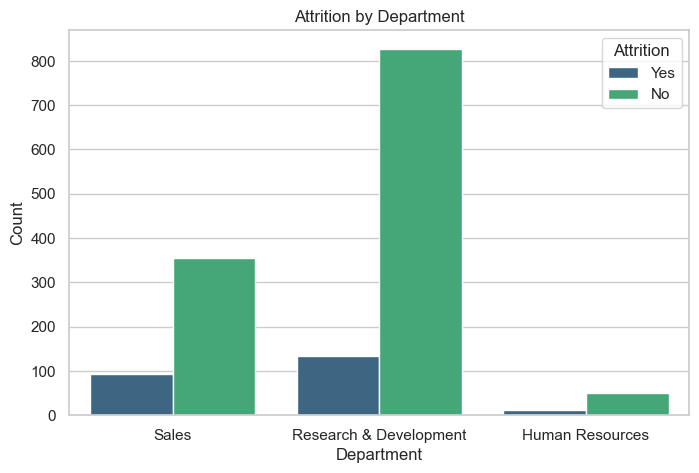

In [42]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Department', hue='Attrition', palette='viridis')
plt.title('Attrition by Department')
plt.xlabel('Department')
plt.ylabel('Count')
plt.legend(title='Attrition')
plt.show()

# This code is showing the attrition by department. Research and Development had the most. 

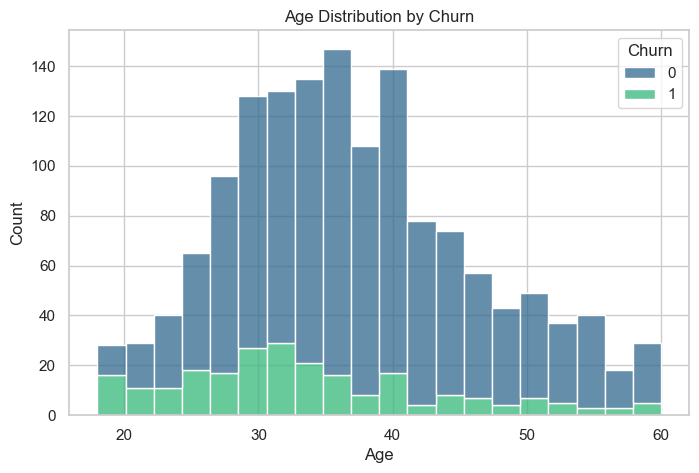

In [43]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age', hue='Churn', multiple='stack', bins=20, palette='viridis')
plt.title('Age Distribution by Churn')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# Shows how churn varies between different age groups 



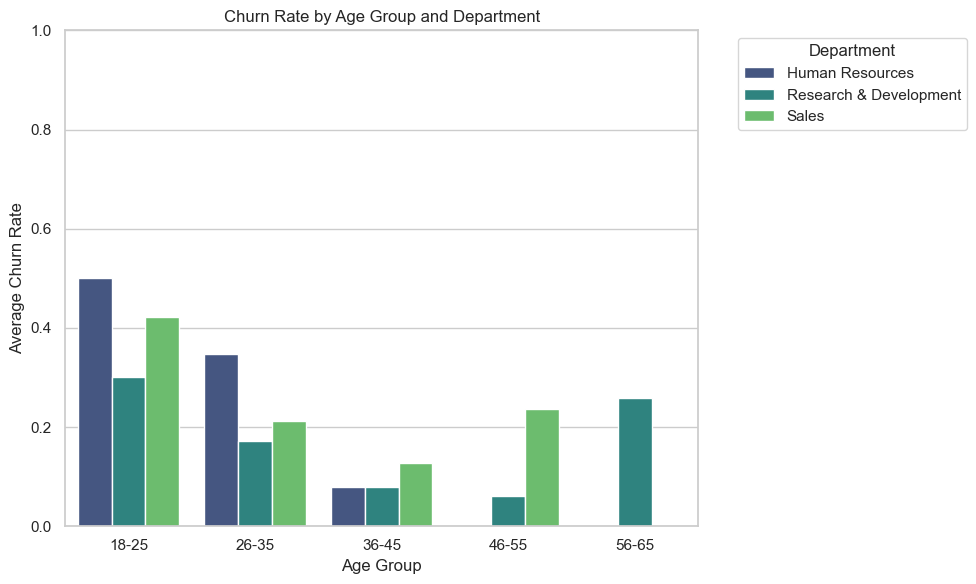

In [66]:
plt.figure(figsize=(10, 6))
sns.barplot(data=churn_age_department, x='AgeGroup', y='Churn', hue='Department', palette='viridis')
plt.title('Churn Rate by Age Group and Department')
plt.xlabel('Age Group')
plt.ylabel('Average Churn Rate')
plt.ylim(0, 1)  # Limit the y-axis to show rates between 0 and 1
plt.legend(title='Department', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()  # Adjust layout for better fit
plt.show()

<Figure size 800x500 with 0 Axes>

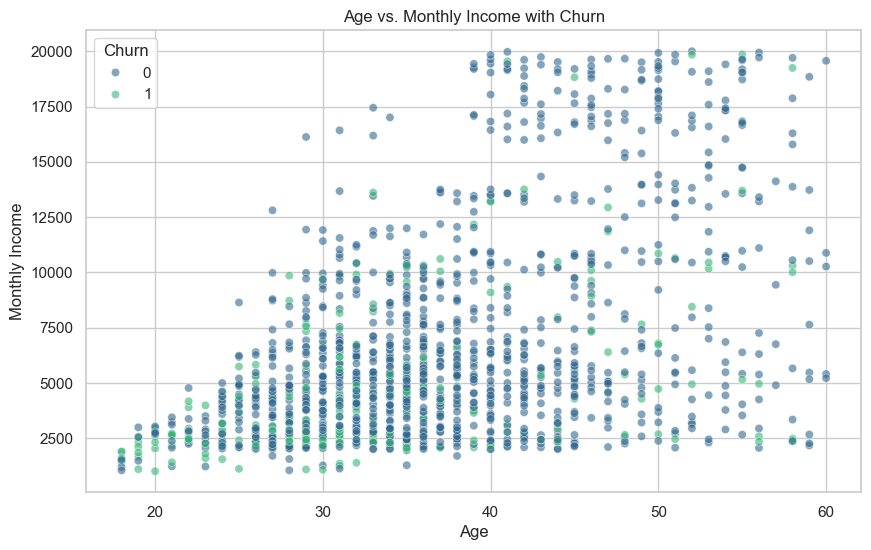

In [52]:
plt.figure(figsize=(10, 6))
if 'MonthlyIncome' in df.columns:
    sns.scatterplot(data=df, x='Age', y='MonthlyIncome', hue='Churn', alpha=0.6, palette='viridis')
    plt.title('Age vs. Monthly Income with Churn')
    plt.xlabel('Age')
    plt.ylabel('Monthly Income')
else:
    print("Column 'MonthlyIncome' not found. Adjust the y-axis column for this plot.")
plt.show()

# A scatter plot that provides a direct view of how age and salary correlate with the liklihood of churn 

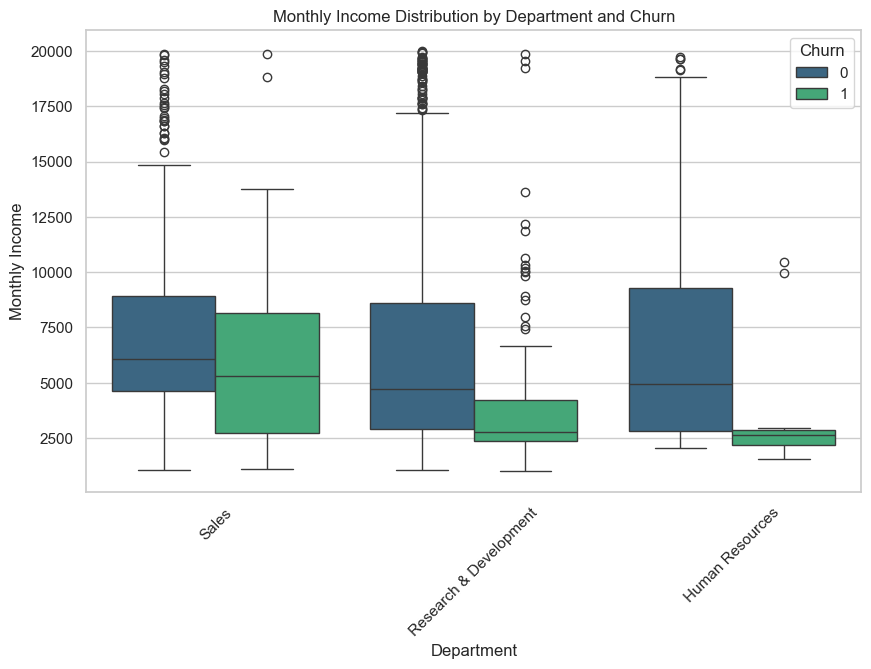

In [53]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Department', y='MonthlyIncome', hue='Churn', palette='viridis')
plt.title('Monthly Income Distribution by Department and Churn')
plt.xlabel('Department')
plt.ylabel('Monthly Income')
plt.legend(title='Churn', loc='upper right')
plt.xticks(rotation=45)
plt.show()

# This shows the spread of monthly income by department and how it relates to churn 



C:\Users\ssarv\AppData\Local\Temp\ipykernel_19108\221727714.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_age_department = df.groupby(['AgeGroup', 'Department'])['Churn'].mean().unstack()


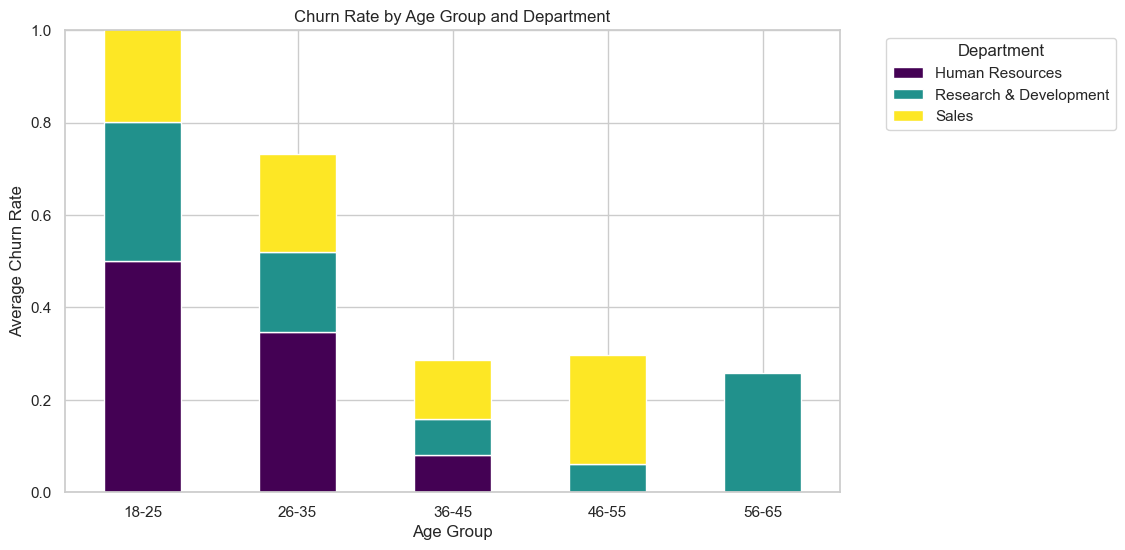

In [54]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[18, 25, 35, 45, 55, 65], labels=['18-25', '26-35', '36-45', '46-55', '56-65'])
churn_age_department = df.groupby(['AgeGroup', 'Department'])['Churn'].mean().unstack()
churn_age_department.plot(kind='bar', figsize=(10, 6), stacked=True, colormap='viridis')
plt.title('Churn Rate by Age Group and Department')
plt.xlabel('Age Group')
plt.ylabel('Average Churn Rate')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(title='Department', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Shows churn rate within each group, separated by departments 

C:\Users\ssarv\AppData\Local\Temp\ipykernel_19108\1959951992.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_income = df.pivot_table(values='MonthlyIncome', index='AgeGroup', columns='Department', aggfunc='mean')


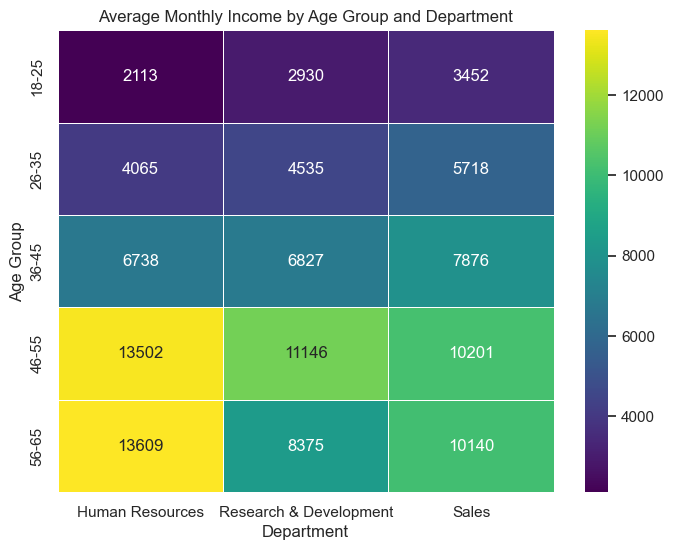

In [55]:
pivot_income = df.pivot_table(values='MonthlyIncome', index='AgeGroup', columns='Department', aggfunc='mean')
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_income, annot=True, fmt='.0f', cmap='viridis', linewidths=0.5)
plt.title('Average Monthly Income by Age Group and Department')
plt.xlabel('Department')
plt.ylabel('Age Group')
plt.show()


In [56]:
summary_stats = df.groupby('Churn')[['Age', 'MonthlyIncome']].mean()
print("Average Age and Monthly Income by Churn Status:")
print(summary_stats)

# Average age and income of employees who left and stayed 

Average Age and Monthly Income by Churn Status:
             Age  MonthlyIncome
Churn                          
0      37.561233    6832.739659
1      33.607595    4787.092827


In [57]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[18, 25, 35, 45, 55, 65], labels=['18-25', '26-35', '36-45', '46-55', '56-65'])
churn_age_department = df.groupby(['AgeGroup', 'Department'])['Churn'].mean().reset_index()
print("\nChurn Rate by Age Group and Department:")
print(churn_age_department)

# Highest churn rate by age group, and which department they are in. 
# Human Resources


Churn Rate by Age Group and Department:
   AgeGroup              Department     Churn
0     18-25         Human Resources  0.500000
1     18-25  Research & Development  0.301370
2     18-25                   Sales  0.421053
3     26-35         Human Resources  0.347826
4     26-35  Research & Development  0.172237
5     26-35                   Sales  0.211340
6     36-45         Human Resources  0.080000
7     36-45  Research & Development  0.078864
8     36-45                   Sales  0.126984
9     46-55         Human Resources  0.000000
10    46-55  Research & Development  0.061644
11    46-55                   Sales  0.236111
12    56-65         Human Resources  0.000000
13    56-65  Research & Development  0.258065
14    56-65                   Sales  0.000000


C:\Users\ssarv\AppData\Local\Temp\ipykernel_19108\2516671054.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_age_department = df.groupby(['AgeGroup', 'Department'])['Churn'].mean().reset_index()


In [58]:
# This provides a quick overview of the linear relationships between these variables.
correlation_matrix = df[['Age', 'MonthlyIncome', 'Churn']].corr()
print("\nCorrelation Matrix for Age, Monthly Income, and Churn:")
print(correlation_matrix)


Correlation Matrix for Age, Monthly Income, and Churn:
                    Age  MonthlyIncome     Churn
Age            1.000000       0.497855 -0.159205
MonthlyIncome  0.497855       1.000000 -0.159840
Churn         -0.159205      -0.159840  1.000000
